In [2]:
import pandas as pd

csv_path = r'H:\HTOC\notebooks\Gap Observation 2.0\TC_Splunk_Address_Index_20260505.csv'
df = pd.read_csv(csv_path)

# Display first few rows to check data
df

,indicator
0,190.110.229.13
1,107.9.57.100
2,154.0.1.1
3,141.94.28.71
4,179.63.54.252
...,...
4061,115.178.58.19
4062,58.80.109.59
4063,185.86.149.223
4064,122.49.215.108


## `results_df` behavioral analysis

This section profiles `results_df` and visualizes how values are distributed across indicator types, scoring fields, tags, and time-like columns.


Shape: (4064, 31)

Column dtypes:


,dtype
id,int64
dateAdded,object
ownerId,int64
ownerName,object
webLink,object
type,object
lastModified,object
rating,float64
confidence,int64
threatAssessRating,float64


,missing_pct
lastFalsePositive,99.901575
source,77.189961
lastObserved,55.880906
associatedGroups.data,32.455709
description,10.531496
tags.data,1.058071


C:\Users\jaskew\AppData\Local\Temp\ipykernel_54932\656789865.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


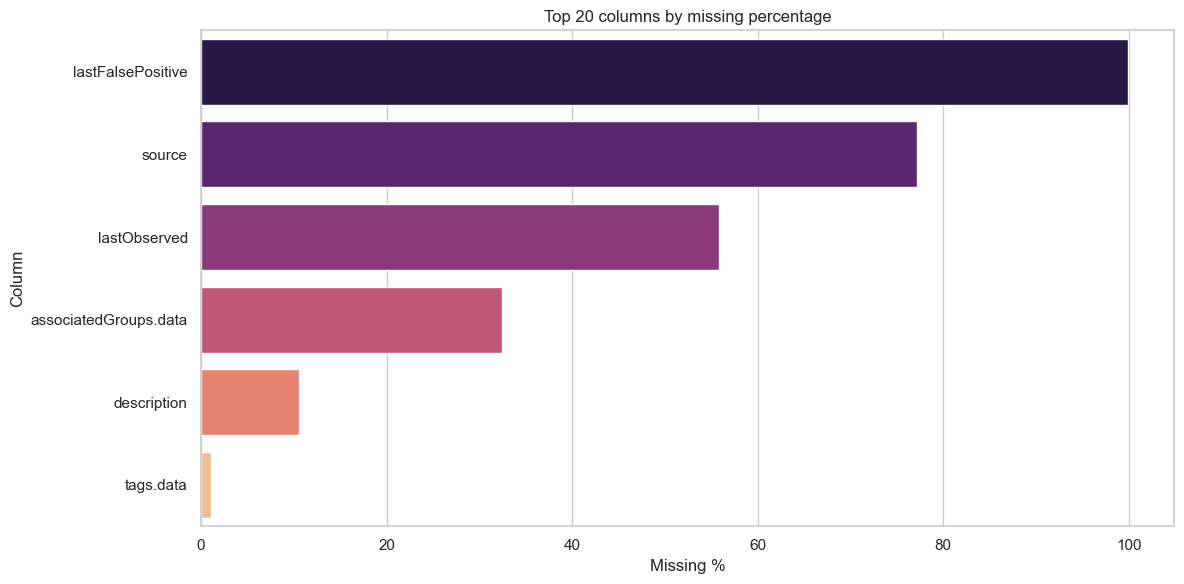

,count
indicator_type,
ipv4,4059
ipv6,5


C:\Users\jaskew\AppData\Local\Temp\ipykernel_54932\656789865.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="viridis")


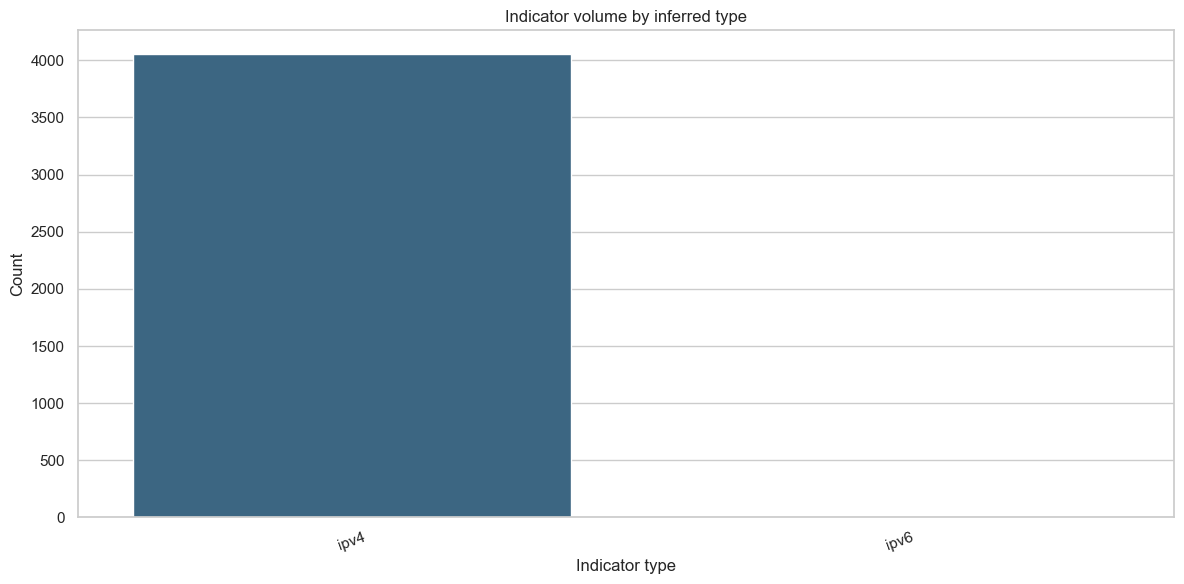

,count,mean,std,min,25%,50%,75%,max
id,4064.0,4.114632e+15,2.930486e+15,11407.00,4504092.75,5.629500e+15,6.755399e+15,6.755399e+15
observations,4064.0,2.341845e+06,1.460780e+07,0.00,0.00,0.000000e+00,7.702000e+03,4.044370e+08
threatAssessScore,4064.0,3.317173e+02,9.491976e+01,140.00,253.75,3.260000e+02,3.680000e+02,8.620000e+02
threatAssessScoreObserved,4064.0,7.056619e+01,8.212135e+01,0.00,0.00,0.000000e+00,1.670000e+02,1.670000e+02
calScore,4064.0,1.875049e+02,7.106361e+01,80.00,170.00,1.800000e+02,1.800000e+02,9.700000e+02
threatAssessConfidence,4064.0,4.130439e+01,1.419751e+01,0.00,32.27,3.700000e+01,4.800000e+01,9.100000e+01
confidence,4064.0,4.401993e+01,9.353576e+00,0.00,37.00,4.600000e+01,4.800000e+01,9.100000e+01
threatAssessScoreFalsePositive,4064.0,-1.643701e-01,5.237321e+00,-167.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00
threatAssessRating,4064.0,2.855472e+00,9.601568e-01,0.33,2.50,2.740000e+00,3.000000e+00,5.000000e+00
rating,4064.0,4.125000e+00,9.172641e-01,1.00,3.00,4.000000e+00,5.000000e+00,5.000000e+00


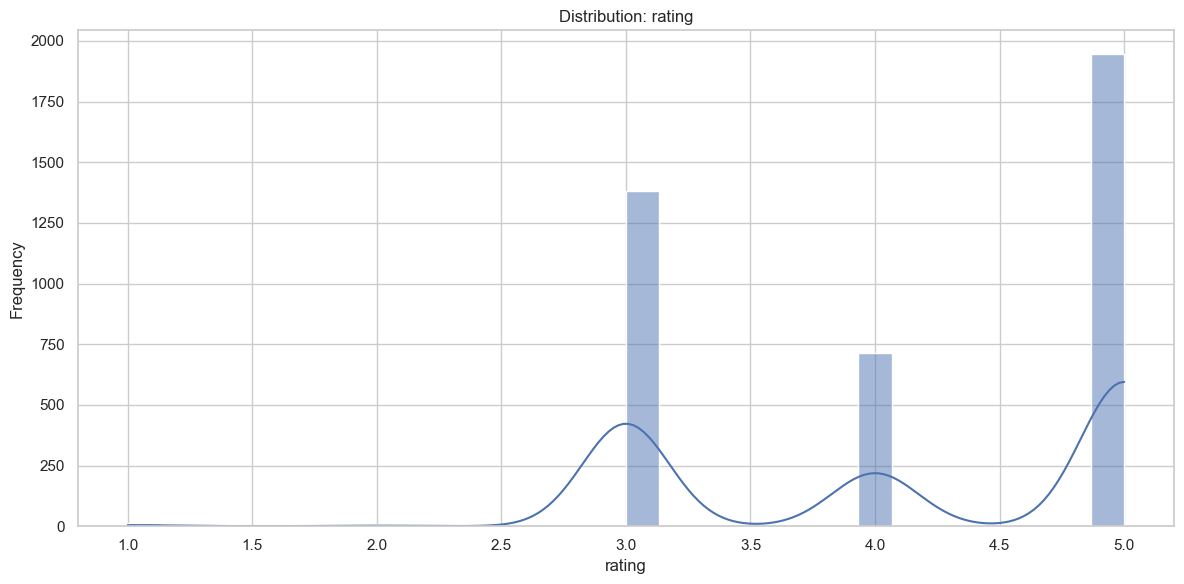

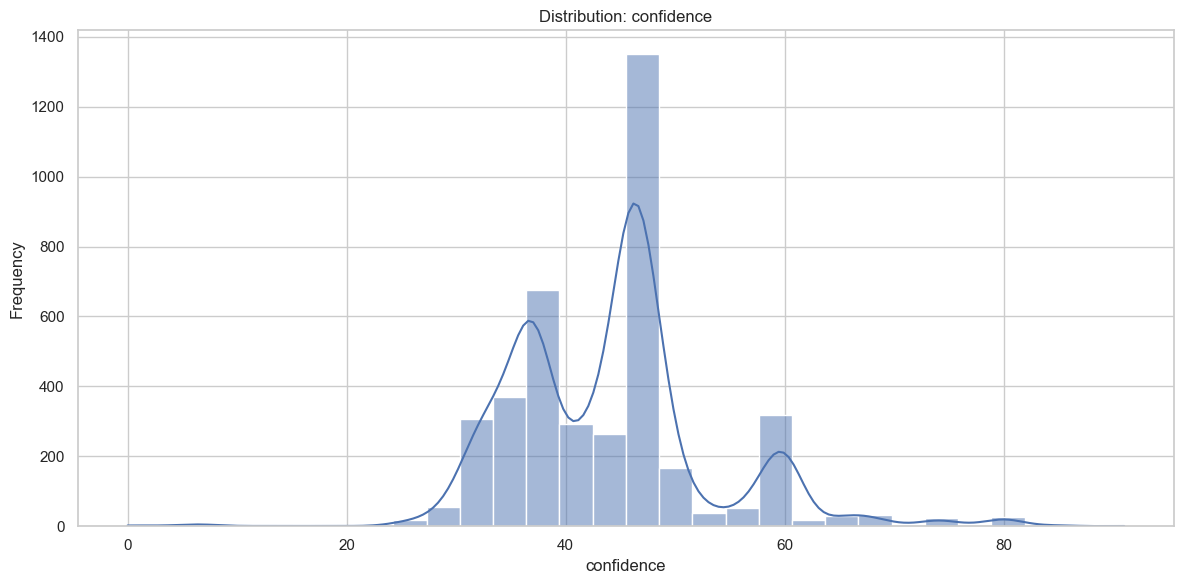

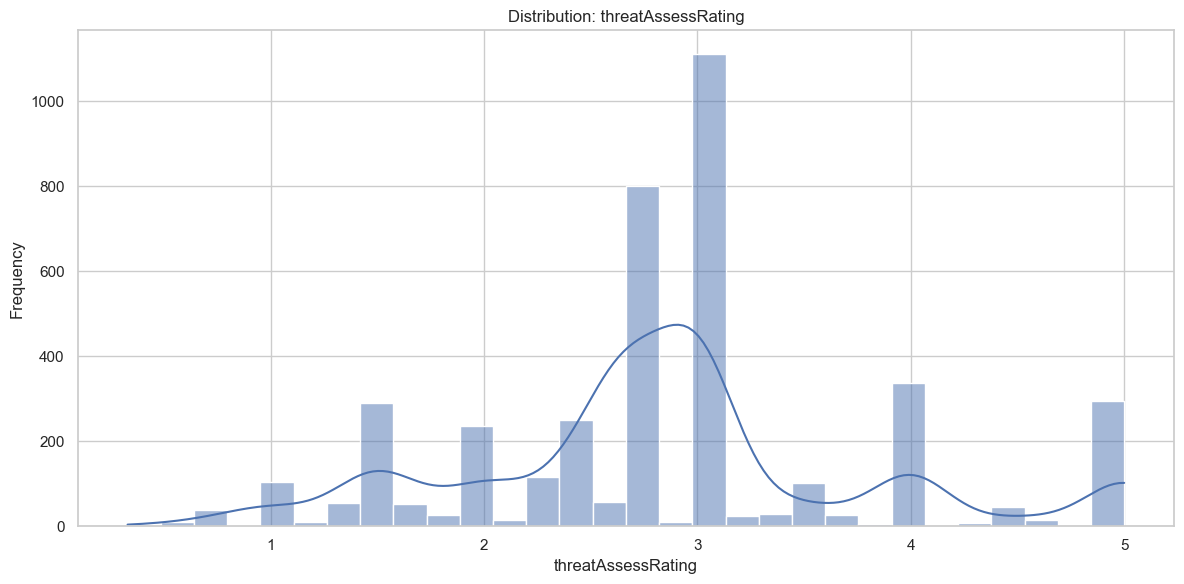

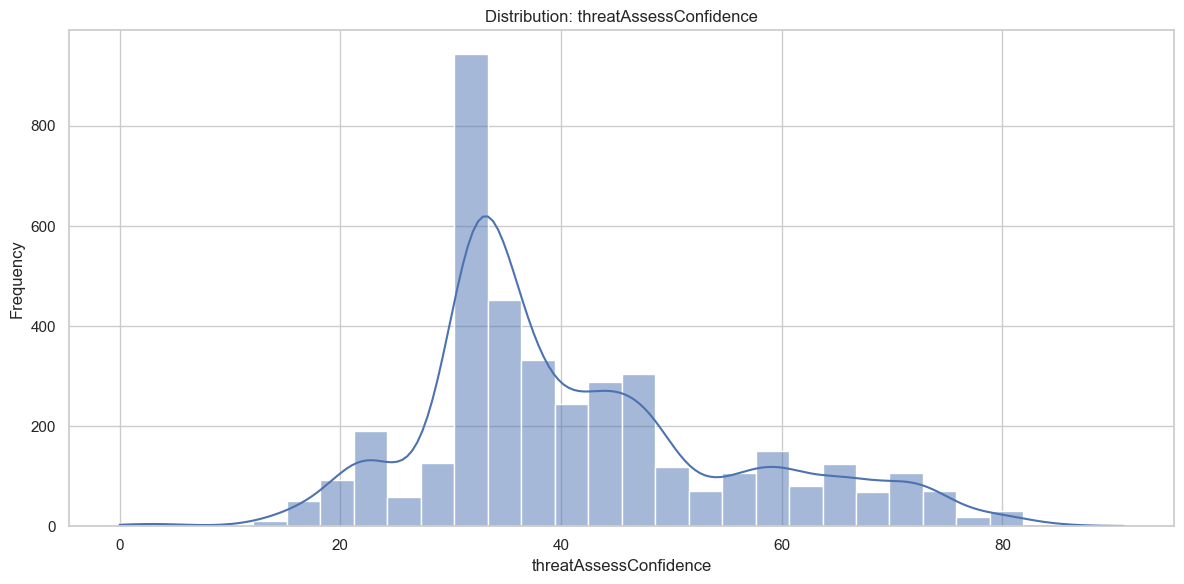

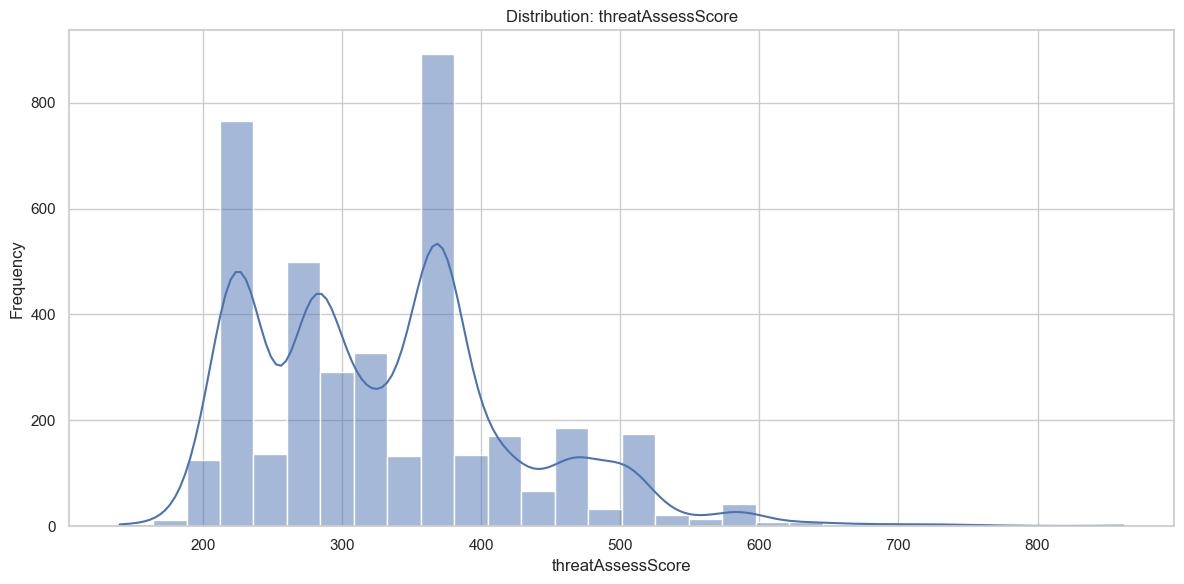

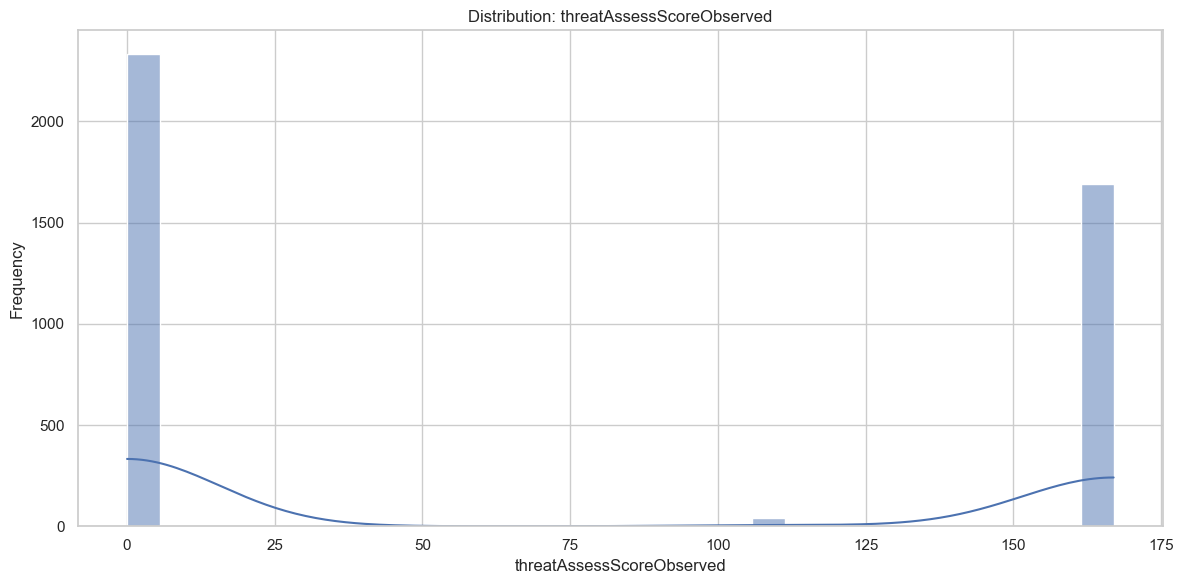

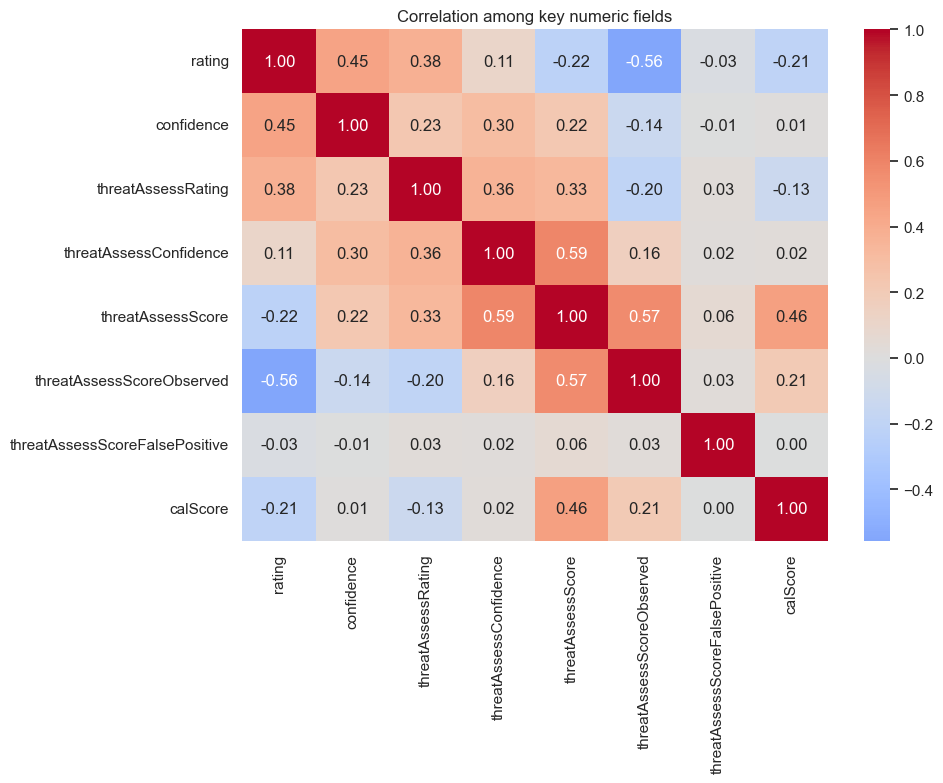

C:\Users\jaskew\AppData\Local\Temp\ipykernel_54932\656789865.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette="crest")
) missing from font(s) Arial.\Temp\ipykernel_54932\656789865.py:135: UserWarning: Glyph 13 (
  plt.tight_layout()
C:\Users\jaskew\AppData\Local\Temp\ipykernel_54932\656789865.py:135: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
) missing from font(s) Arial.ng\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


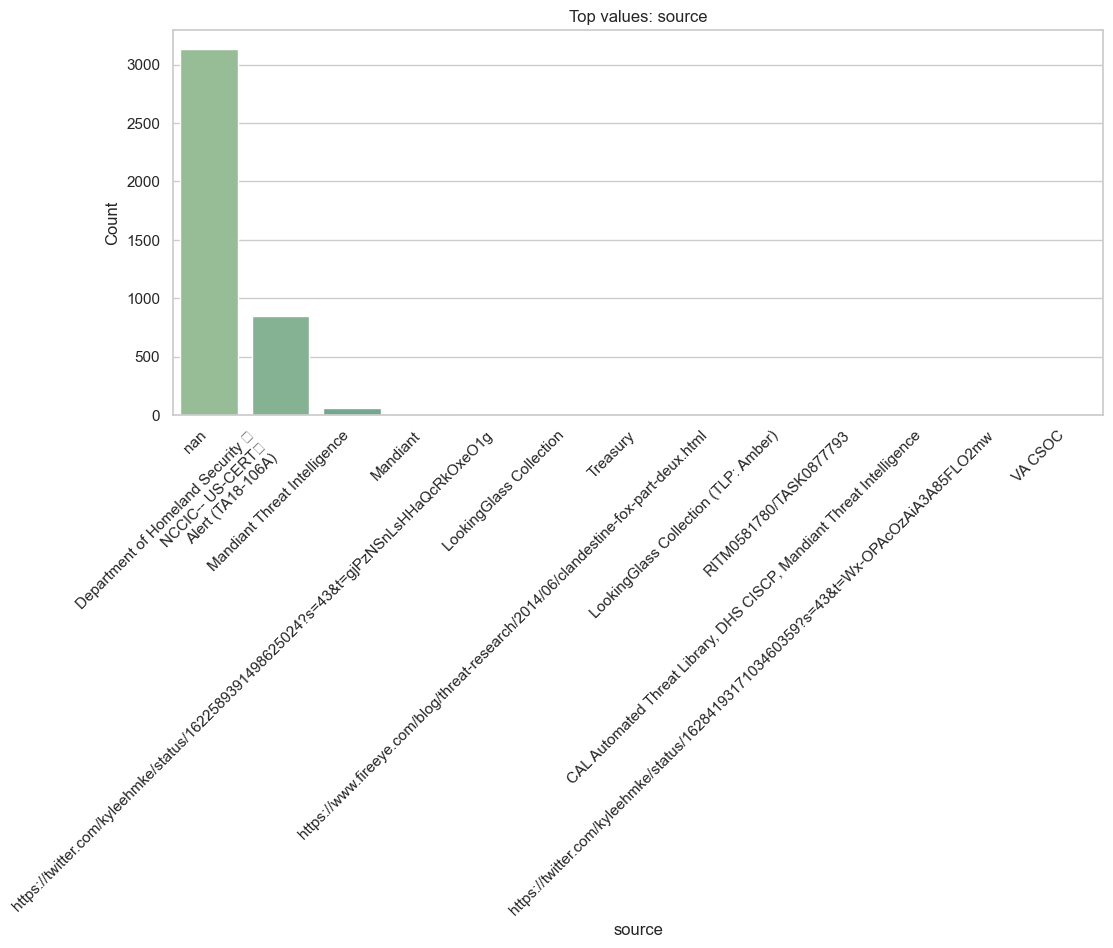

C:\Users\jaskew\AppData\Local\Temp\ipykernel_54932\656789865.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette="crest")


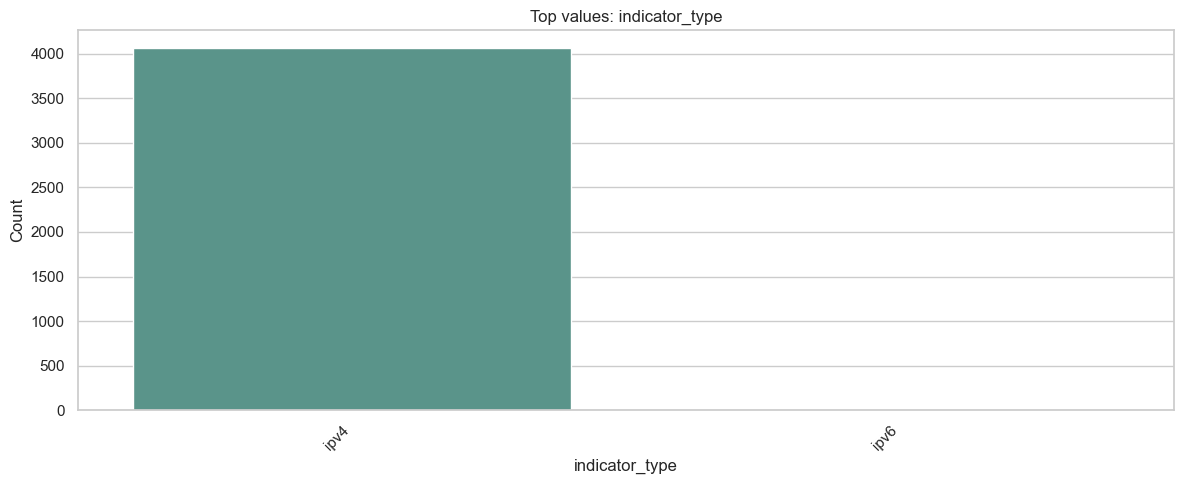

,count
tags.data,
Observed,1715
VA CSOC CTS Splunk,1323
SOAR Indicator PB,1291
CMS Splunk API,1259
OS Splunk API,1244
malicious,1229
FDA Splunk API,1175
DHA Splunk API,1167
IHS Splunk API,1074


In [ ]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

if "results_df" not in globals():
    raise NameError("results_df is not defined. Run the data-retrieval cell first.")
if results_df.empty:
    raise ValueError("results_df is empty. No data to analyze.")

analysis_df = results_df.copy()

print("Shape:", analysis_df.shape)
print("\nColumn dtypes:")
display(analysis_df.dtypes.rename("dtype").to_frame())

# --- 1) Missingness profile (top columns with nulls) ---
missing_pct = (analysis_df.isna().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

if not missing_nonzero.empty:
    display(missing_nonzero.rename("missing_pct").to_frame().head(25))
    plt.figure()
    sns.barplot(
        x=missing_nonzero.head(20).values,
        y=missing_nonzero.head(20).index,
        palette="magma"
    )
    plt.title("Top 20 columns by missing percentage")
    plt.xlabel("Missing %")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

# --- 2) Indicator behavior by type ---
if "indicator" in analysis_df.columns:
    ind = analysis_df["indicator"].astype(str).str.strip().str.lower()

    ip_v4 = r"^(?:\d{1,3}\.){3}\d{1,3}$"
    ip_v6 = r"^[0-9a-f:]+$"
    domain_like = r"^[a-z0-9][a-z0-9.-]*\.[a-z]{2,}$"
    url_like = r"^(http|https|ftp)://"
    hash_like = r"^[a-f0-9]{32,64}$"

    indicator_type = np.select(
        [
            ind.str.match(url_like, na=False),
            ind.str.match(ip_v4, na=False),
            ind.str.match(ip_v6, na=False) & ind.str.contains(":", regex=False),
            ind.str.match(hash_like, na=False),
            ind.str.match(domain_like, na=False),
        ],
        ["url", "ipv4", "ipv6", "hash", "domain"],
        default="other",
    )

    analysis_df["indicator_type"] = indicator_type

    type_counts = analysis_df["indicator_type"].value_counts(dropna=False)
    display(type_counts.rename("count").to_frame())

    plt.figure()
    sns.barplot(x=type_counts.index, y=type_counts.values, palette="viridis")
    plt.title("Indicator volume by inferred type")
    plt.xlabel("Indicator type")
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# --- 3) Numeric field distributions ---
numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    numeric_summary = analysis_df[numeric_cols].describe().T.sort_values("std", ascending=False)
    display(numeric_summary.head(25))

    # Focus on likely risk/scoring metrics first
    score_like = [
        c for c in numeric_cols
        if any(k in c.lower() for k in ["score", "threat", "confidence", "rating", "severity"])
    ]
    plot_cols = (score_like[:6] if score_like else numeric_cols[:6])

    for col in plot_cols:
        plt.figure()
        sns.histplot(analysis_df[col].dropna(), kde=True, bins=30, color="#4C72B0")
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

    # Correlation heatmap on a manageable subset
    corr_cols = (score_like[:10] if len(score_like) >= 2 else numeric_cols[:10])
    if len(corr_cols) >= 2:
        plt.figure(figsize=(10, 8))
        corr_matrix = analysis_df[corr_cols].corr(numeric_only=True)
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title("Correlation among key numeric fields")
        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns detected.")

# --- 4) Top categories in object/string columns ---
obj_cols = analysis_df.select_dtypes(include=["object", "string"]).columns.tolist()

def _to_hashable_repr(v):
    if isinstance(v, (list, dict, set, tuple)):
        return repr(v)
    return v

candidate_cat_cols = []
for c in obj_cols:
    normalized = analysis_df[c].map(_to_hashable_repr)
    uniq = normalized.nunique(dropna=True)
    if 1 < uniq <= 50:
        candidate_cat_cols.append(c)

for col in candidate_cat_cols[:6]:
    vc = analysis_df[col].map(_to_hashable_repr).astype(str).value_counts(dropna=False).head(15)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=vc.index, y=vc.values, palette="crest")
    plt.title(f"Top values: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# --- 5) Tag activity (if tags-like column exists) ---
tag_cols = [c for c in analysis_df.columns if "tag" in c.lower()]

def _extract_tags(cell):
    if isinstance(cell, list):
        vals = []
        for x in cell:
            if isinstance(x, dict):
                vals.append(str(x.get("name", "")).strip())
            else:
                vals.append(str(x).strip())
        return [v for v in vals if v]
    if isinstance(cell, dict):
        return [str(cell.get("name", "")).strip()] if cell.get("name") else []
    if pd.isna(cell):
        return []
    raw = str(cell).strip()
    if not raw:
        return []
    return [t.strip() for t in re.split(r"[,;|]", raw) if t.strip()]

if tag_cols:
    tag_col = tag_cols[0]
    exploded_tags = analysis_df[tag_col].apply(_extract_tags).explode().dropna()
    if not exploded_tags.empty:
        top_tags = exploded_tags.value_counts().head(20)
        display(top_tags.rename("count").to_frame())

        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_tags.values, y=top_tags.index, palette="flare")
        plt.title(f"Top tags from: {tag_col}")
        plt.xlabel("Count")
        plt.ylabel("Tag")
        plt.tight_layout()
        plt.show()

# --- 6) Time behavior (created/modified/lastSeen-like columns) ---
time_candidates = [
    c for c in analysis_df.columns
    if any(k in c.lower() for k in ["date", "time", "created", "modified", "lastseen", "firstseen", "observed"])
]

parsed_time = {}
for c in time_candidates:
    ts = pd.to_datetime(analysis_df[c], errors="coerce", utc=True)
    if ts.notna().mean() > 0.5:
        parsed_time[c] = ts

for c, ts in list(parsed_time.items())[:3]:
    daily_counts = ts.dt.floor("D").value_counts().sort_index()
    if not daily_counts.empty:
        plt.figure(figsize=(12, 5))
        sns.lineplot(x=daily_counts.index, y=daily_counts.values, marker="o")
        plt.title(f"Daily record activity: {c}")
        plt.xlabel("Date")
        plt.ylabel("Records")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

# --- 7) Dedicated date field analysis ---
if "dateAdded" in analysis_df.columns:
    date_added = pd.to_datetime(analysis_df["dateAdded"], errors="coerce", utc=True)
    valid_rate = date_added.notna().mean() * 100
    print(f"dateAdded parse success: {valid_rate:.1f}%")

    monthly_counts = date_added.dt.to_period("M").value_counts().sort_index()
    if not monthly_counts.empty:
        plt.figure(figsize=(12, 5))
        sns.lineplot(x=monthly_counts.index.astype(str), y=monthly_counts.values, marker="o")
        plt.title("Monthly indicator additions (dateAdded)")
        plt.xlabel("Month")
        plt.ylabel("Records added")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    dow = date_added.dt.day_name().value_counts().reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    )
    if dow.notna().any():
        plt.figure(figsize=(10, 4))
        sns.barplot(x=dow.index, y=dow.fillna(0).values, palette="Blues_d")
        plt.title("dateAdded distribution by day of week")
        plt.xlabel("Day of week")
        plt.ylabel("Count")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

# --- 8) Description field analysis ---
if "description" in analysis_df.columns:
    desc = analysis_df["description"].fillna("").astype(str)
    has_desc = desc.str.strip().ne("")

    print(f"Descriptions present: {has_desc.mean() * 100:.1f}%")

    desc_len = desc.str.len()
    word_count = desc.str.findall(r"\b\w+\b").str.len()

    plt.figure(figsize=(12, 5))
    sns.histplot(desc_len[has_desc], bins=40, kde=True, color="#55A868")
    plt.title("Description length distribution (characters)")
    plt.xlabel("Characters")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.histplot(word_count[has_desc], bins=40, kde=True, color="#C44E52")
    plt.title("Description length distribution (words)")
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    stop_words = {
        "the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "with", "is", "are", "was", "were",
        "this", "that", "it", "as", "at", "be", "by", "from", "has", "have", "had", "not", "but"
    }
    tokens = (
        desc[has_desc]
        .str.lower()
        .str.findall(r"[a-z0-9_\-]{3,}")
        .explode()
        .dropna()
    )
    if not tokens.empty:
        tokens = tokens[~tokens.isin(stop_words)]
        top_terms = tokens.value_counts().head(20)
        if not top_terms.empty:
            display(top_terms.rename("count").to_frame())
            plt.figure(figsize=(12, 6))
            sns.barplot(x=top_terms.values, y=top_terms.index, palette="rocket")
            plt.title("Top terms in description")
            plt.xlabel("Term frequency")
            plt.ylabel("Term")
            plt.tight_layout()
            plt.show()

# --- 9) Nested *.data field analysis ---
data_cols = [c for c in analysis_df.columns if c.lower().endswith(".data") or c.lower() == "data"]

for dcol in data_cols:
    series = analysis_df[dcol]

    def _to_items(v):
        if isinstance(v, list):
            return v
        if isinstance(v, dict):
            return [v]
        if pd.isna(v):
            return []
        return []

    items = series.apply(_to_items)
    has_items = items.apply(len).gt(0)
    counts = items.apply(len)

    print(f"\n{dcol} -> rows with data: {has_items.mean() * 100:.1f}%")

    plt.figure(figsize=(10, 4))
    sns.histplot(counts, bins=30, kde=True, color="#8172B2")
    plt.title(f"Items per row in {dcol}")
    plt.xlabel("Item count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    exploded = items.explode().dropna()
    if not exploded.empty:
        # Prefer common object keys for readable top-entity analysis
        if exploded.map(lambda x: isinstance(x, dict)).all():
            candidate_keys = ["name", "type", "summary", "id"]
            picked_key = None
            for k in candidate_keys:
                vals = exploded.map(lambda x: x.get(k) if isinstance(x, dict) else None)
                if vals.notna().sum() > 0:
                    picked_key = k
                    break

            if picked_key:
                top_entities = (
                    exploded.map(lambda x: x.get(picked_key) if isinstance(x, dict) else None)
                    .dropna()
                    .astype(str)
                    .value_counts()
                    .head(20)
                )
                if not top_entities.empty:
                    display(top_entities.rename("count").to_frame())
                    plt.figure(figsize=(12, 6))
                    sns.barplot(x=top_entities.values, y=top_entities.index, palette="mako")
                    plt.title(f"Top {picked_key} values in {dcol}")
                    plt.xlabel("Count")
                    plt.ylabel(picked_key)
                    plt.tight_layout()
                    plt.show()

print("EDA charts generated. Review each section to see how the dataset behaves.")


In [ ]:
import sys
import os
import urllib3
from configparser import ConfigParser

# Add your local ThreatConnect SDK to path
sys.path.append(r"Z:\HTOC\Data_Analytics\threatconnect")
from ThreatConnect import ThreatConnect
from RequestObject import RequestObject
from Owners import Owners

# Add your project repo to path
project_root = r"H:\HTOC\scripts\Data Movement\ThrearConnect-api-pull"
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.config_loader import load_config

# Load API config
config_path = os.path.join(project_root, "utils", "config.json")
try:
    api_secret_key, api_access_id, api_base_url, api_default_org = load_config(config_path)
    display(f"Loaded config from: {config_path}")
    display(f"Base URL: {api_base_url}")
    display(f"Access ID: {api_access_id}")
    display(f"Default Org: {api_default_org}")
except Exception as e:
    display(f"[ERROR] Failed to load configuration: {e}")
    sys.exit(1)

# Disable SSL verification warnings (use cautiously)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
verify_ssl = False

# Initialize ThreatConnect session
try:
    tc = ThreatConnect(api_access_id, api_secret_key, api_default_org, api_base_url)
    display("ThreatConnect initialized.")
except Exception as e:
    display(f"[ERROR] Failed to initialize ThreatConnect: {e}")
    sys.exit(1)

# Define the owner (organization scope)
owner = 'HTOC Org'

# Create a request object to fetch indicators (or other data)
try:
    ro = RequestObject()
    ro.set_http_method('GET')
    ro.set_owner(owner)
    ro.set_owner_allowed(True)
    # ro.set_resource_pagination(True)  # Uncomment if needed
    display("RequestObject successfully created.")
except Exception as e:
    display(f"[ERROR] Failed to initialize RequestObject: {e}")
    sys.exit(1)




'Loaded config from: H:\\HTOC\\scripts\\Data Movement\\ThrearConnect-api-pull\\utils\\config.json'

'Base URL: https://hvs.threatconnect.com/api'

'Access ID: 09783848890162390382'

'Default Org: HTOC Org'

'ThreatConnect initialized.'

'RequestObject successfully created.'

In [ ]:
import urllib.parse
import pandas as pd

# Build indicator list: Splunk_data indicators not present in tc_data
splunk_indicators = set(df["indicator"].astype(str).str.strip().str.split().str[0])
indicators = sorted(splunk_indicators)
print(f"Indicators to query (Splunk not in tc_data): {len(indicators):,}")

retrieved_items = []
not_found = []

for idx, indicator in enumerate(indicators, start=1):
    encoded_indicator = urllib.parse.quote(indicator, safe="")

    ro_item = RequestObject()
    ro_item.set_http_method("GET")
    ro_item.set_request_uri(
        f"/v3/indicators/{encoded_indicator}"
        f"?fields=tags,observations,associatedGroups,falsePositives,threatAssess"
    )

    try:
        response = tc.api_request(ro_item)
        ct = response.headers.get("content-type", "")
        if not ct.startswith("application/json"):
            not_found.append(indicator)
            continue

        body = response.json() or {}
        data = body.get("data")

        if isinstance(data, dict):
            retrieved_items.append(data)
        elif isinstance(data, list) and data:
            retrieved_items.extend([x for x in data if isinstance(x, dict)])
        else:
            not_found.append(indicator)
    except Exception:
        not_found.append(indicator)

    if idx % 200 == 0:
        print(f"Processed {idx:,}/{len(indicators):,}")

if retrieved_items:
    results_df = pd.json_normalize(retrieved_items)
    if "summary" in results_df.columns:
        results_df["indicator"] = results_df["summary"].astype(str).str.split().str[0].str.strip()
    results_df = results_df.drop_duplicates(subset=["indicator"]).reset_index(drop=True)
else:
    results_df = pd.DataFrame()

print(f"Retrieved from TC: {len(results_df):,}")
print(f"Not found: {len(not_found):,}")
display(results_df)

Indicators to query (Splunk not in tc_data): 4,066
Processed 200/4,066
Processed 400/4,066
Processed 600/4,066


Status Code: 400
Failed API Response: b'{"errCode":"0x1001","message":"No indicator found. Try looking up by ID instead (1).","status":"Error"}'


Processed 800/4,066
Processed 1,000/4,066
Processed 1,200/4,066
Processed 1,400/4,066
Processed 1,600/4,066
Processed 1,800/4,066
Processed 2,000/4,066
Processed 2,200/4,066
Processed 2,400/4,066


Status Code: 400
Failed API Response: b'{"errCode":"0x1001","message":"No indicator found. Try looking up by ID instead (1).","status":"Error"}'


Processed 2,600/4,066
Processed 2,800/4,066
Processed 3,000/4,066
Processed 3,200/4,066
Processed 3,400/4,066
Processed 3,600/4,066
Processed 3,800/4,066
Processed 4,000/4,066
Retrieved from TC: 4,064
Not found: 2


,id,dateAdded,ownerId,ownerName,webLink,type,lastModified,rating,confidence,threatAssessRating,...,privateFlag,active,activeLocked,ip,legacyLink,tags.data,associatedGroups.data,lastObserved,lastFalsePositive,indicator
0,234298,2017-01-03T15:27:15Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-03T07:15:13Z,5.0,46,2.68,...,False,True,False,1.112.1.1,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 157678, 'dateAdded': '2023-08-02T13:24...",NaN,NaN,1.112.1.1
1,5629499559324031,2025-07-14T18:49:57Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,3.0,29,3.00,...,False,True,False,1.116.139.11,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 6755399453000829, 'dateAdded': '2025-0...",NaN,NaN,1.116.139.11
2,5629499558103699,2025-07-09T16:54:01Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:33Z,5.0,60,5.00,...,False,True,False,1.13.188.57,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 43, 'name': 'China', 'lastUsed': '2026...","[{'id': 5629499545001809, 'dateAdded': '2025-0...",NaN,NaN,1.13.188.57
3,6755399447111259,2025-05-14T17:47:35Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T17:12:36Z,3.0,32,1.50,...,False,True,False,1.192.18.4,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 23576, 'name': 'Observed', 'lastUsed':...",NaN,2026-04-21T00:00:00Z,NaN,1.192.18.4
4,234303,2017-01-03T15:27:15Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-03T07:18:52Z,5.0,46,2.68,...,False,True,False,1.212.1.1,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 157678, 'dateAdded': '2023-08-02T13:24...",NaN,NaN,1.212.1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4059,6755399444006146,2025-04-22T15:45:29Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:33Z,5.0,48,5.00,...,False,True,False,98.100.141.70,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 39766, 'name': 'scattered spider', 'la...","[{'id': 315445, 'dateAdded': '2024-02-13T16:25...",NaN,NaN,98.100.141.70
4060,234417,2017-01-03T15:27:15Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:59Z,5.0,47,2.68,...,False,True,False,98.138.199.240,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 157678, 'dateAdded': '2023-08-02T13:24...",NaN,NaN,98.138.199.240
4061,5629499558103777,2025-07-09T16:54:02Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:33Z,5.0,60,5.00,...,False,True,False,98.142.253.117,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 43, 'name': 'China', 'lastUsed': '2026...","[{'id': 5629499545001809, 'dateAdded': '2025-0...",NaN,NaN,98.142.253.117
4062,5629499558103778,2025-07-09T16:54:02Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:59Z,5.0,60,3.00,...,False,True,False,98.142.253.173,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 43, 'name': 'China', 'lastUsed': '2026...","[{'id': 5629499545001809, 'dateAdded': '2025-0...",NaN,NaN,98.142.253.173
